#### 타이타닉 데이터 분석
- 데이터 분석에 사용할 라이브러리 로드
- 타이타닉 데이터 불러오기
- 데이터 확인

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import koreanize_matplotlib

In [2]:
df = pd.read_csv('train.csv')
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [2]:
pd.options.display.max_columns = 50

##### 데이터 상태 점검
- 전체 구조 확인
- 결측치 확인

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.shape

(891, 12)

In [5]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

##### 결측치 처리
- 나이는 평균값으로 채우고 확인

In [6]:
mean_age = df['Age'].mean()
mean_age

np.float64(29.69911764705882)

In [7]:
df['Age'] = df['Age'].fillna(mean_age)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age              0
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

#### 성별 그룹화하여 생존여부 확인
- 성별을 그룹화하고 생존의 평균 구하여 확인

In [8]:
survived_by_sex = df.groupby('Sex')['Survived'].mean()
survived_by_sex

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

#### 시각화

In [9]:
!pip install koreanize-matplotlib

In [10]:
# 한글깨짐 방지용
import koreanize_matplotlib 

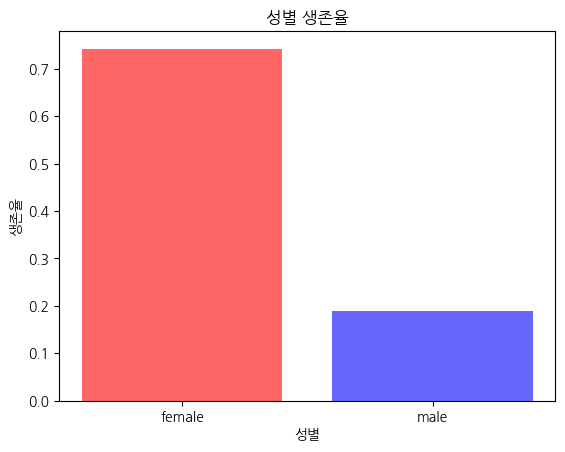

In [11]:
plt.bar(survived_by_sex.index, survived_by_sex, color=['red','blue'], alpha=0.6)
plt.title('성별 생존율')
plt.xlabel('성별')
plt.ylabel('생존율')
plt.show()

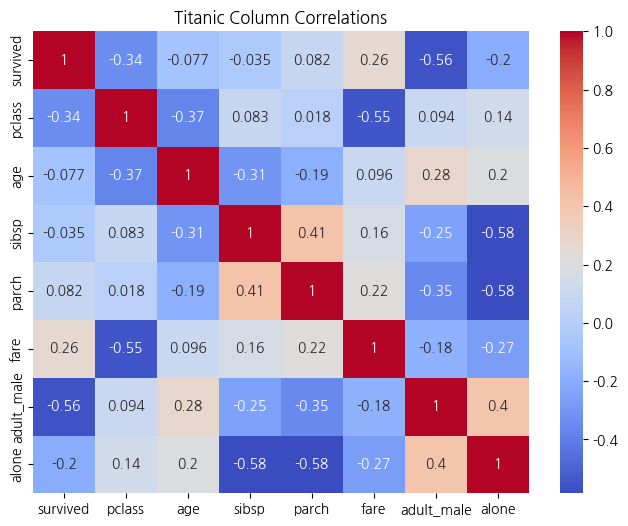

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

# 타이타닉 데이터 로드
df = sns.load_dataset('titanic')

# 숫자형 데이터만 골라서 상관관계 분석
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Titanic Column Correlations')
plt.show()

<Axes: xlabel='pclass', ylabel='fare'>

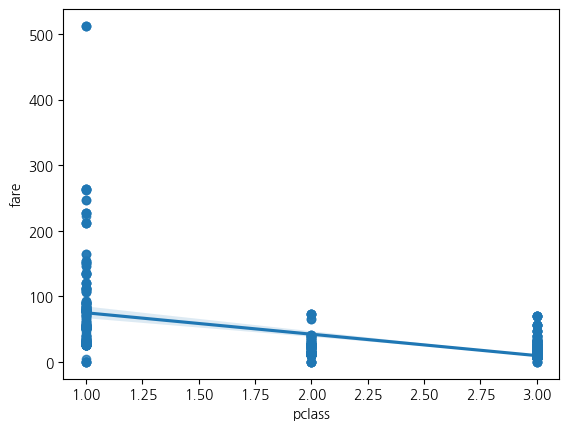

In [4]:
import seaborn as sns
# 등급(pclass)과 요금(fare)의 반비례 관계 확인하기
sns.regplot(x='pclass', y='fare', data=df)